# Parent RFM versus RFD â€” paired BW plot lab

Interactive results for the completed 576-draw fixed-rank comparison. Every row uses identical synthetic observations, known rank, and the same two lags for complete RFD and the cloned parent `rfm_bws`.

**Scope:** recovery and reconstruction only. These are not forecasts. `P-HOME` is an identity-centred geometric home field, not a byte-for-byte replay of the parent's generator.

In [1]:
from pathlib import Path
from IPython.display import display
import sys

ROOT = Path.cwd()
if not (ROOT / "results").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from experiments.analyze_parent_rfd_bw_parity import (
    build_cells,
    centre_exponents,
    headline_table,
    health_table,
    load_results,
    parent_mean_sensitivity,
    plot_centre_rate,
    plot_centre_vs_signal,
    plot_loading_and_score_gain,
    plot_observation_vs_signal,
    plot_paired_gain,
    plot_parent_mean_sensitivity,
    plot_runtime,
    plot_signal_gain_heatmap,
    plot_signal_reconstruction,
    runtime_table,
    win_table,
)

EXPORT = False
EXPORT_DIR = (
    ROOT / "results" / "figures" / "parent_rfd_bw_parity"
    if EXPORT else None
)
raw, supplied_summary = load_results(ROOT)
cells = build_cells(raw)

print("rows:", len(raw))
print("EXPORT:", EXPORT)
print("source:", (ROOT / "results/intermediate/parent_rfd_bw_parity/raw.csv").relative_to(ROOT))

rows: 576
EXPORT: False
source: results\intermediate\parent_rfd_bw_parity\raw.csv


## Numerical health

The notebook refuses to proceed if rows are missing, duplicated, nonfinite, failed, or contain undeclared RFD fallbacks.

In [2]:
display(health_table(raw))

,check,value
0,paired rows,576.000000
1,duplicate task keys,0.000000
2,fatal/partial rows,0.000000
3,parent failures,0.000000
4,RFD fallbacks,0.000000
5,RFD nonconverged stages,0.000000
6,minimum observed eigenvalue,0.034071


## Headline numbers

Positive percentages mean RFD has lower error. Negative percentages mean the parent has lower error.

In [3]:
headline = headline_table(cells, n=8192)
for column in ["RFD signal RMS", "parent signal RMS"]:
    headline[column] = headline[column].map(lambda value: f"{value:.4f}")
for column in ["signal gain (%)", "loading gain (%)"]:
    headline[column] = headline[column].map(lambda value: f"{value:+.1f}%")
for column in ["RFD score NRMSE", "parent score NRMSE"]:
    headline[column] = headline[column].map(lambda value: f"{value:.1%}")
display(headline)

wins = win_table(raw)
display(wins.pivot(index="scenario", columns="n", values="RFD wins"))

,scenario,RFD signal RMS,parent signal RMS,signal gain (%),loading gain (%),RFD score NRMSE,parent score NRMSE
0,parent home,0.0350,0.0346,-1.0%,+2.5%,38.5%,27.6%
1,fixed control,0.0355,0.0351,-1.0%,-12.6%,40.1%,28.0%
2,aligned,0.0354,0.0350,-1.0%,-11.8%,38.5%,73.2%
3,mixed,0.0353,0.0614,+42.5%,+96.3%,39.6%,68.6%
4,orthogonal,0.0349,0.0825,+57.8%,+98.3%,37.9%,93.0%
5,curved,0.0351,0.0795,+55.8%,+97.9%,38.1%,79.9%


n,240,512,2048,8192
scenario,,,,
aligned,0,0,0,0
curved,24,24,24,24
fixed control,0,0,0,0
mixed,24,24,24,24
orthogonal,24,24,24,24
parent home,0,0,0,0


## Primary outcome â€” latent-signal reconstruction

Lines are medians and ribbons are interquartile ranges across 24 paired draws.

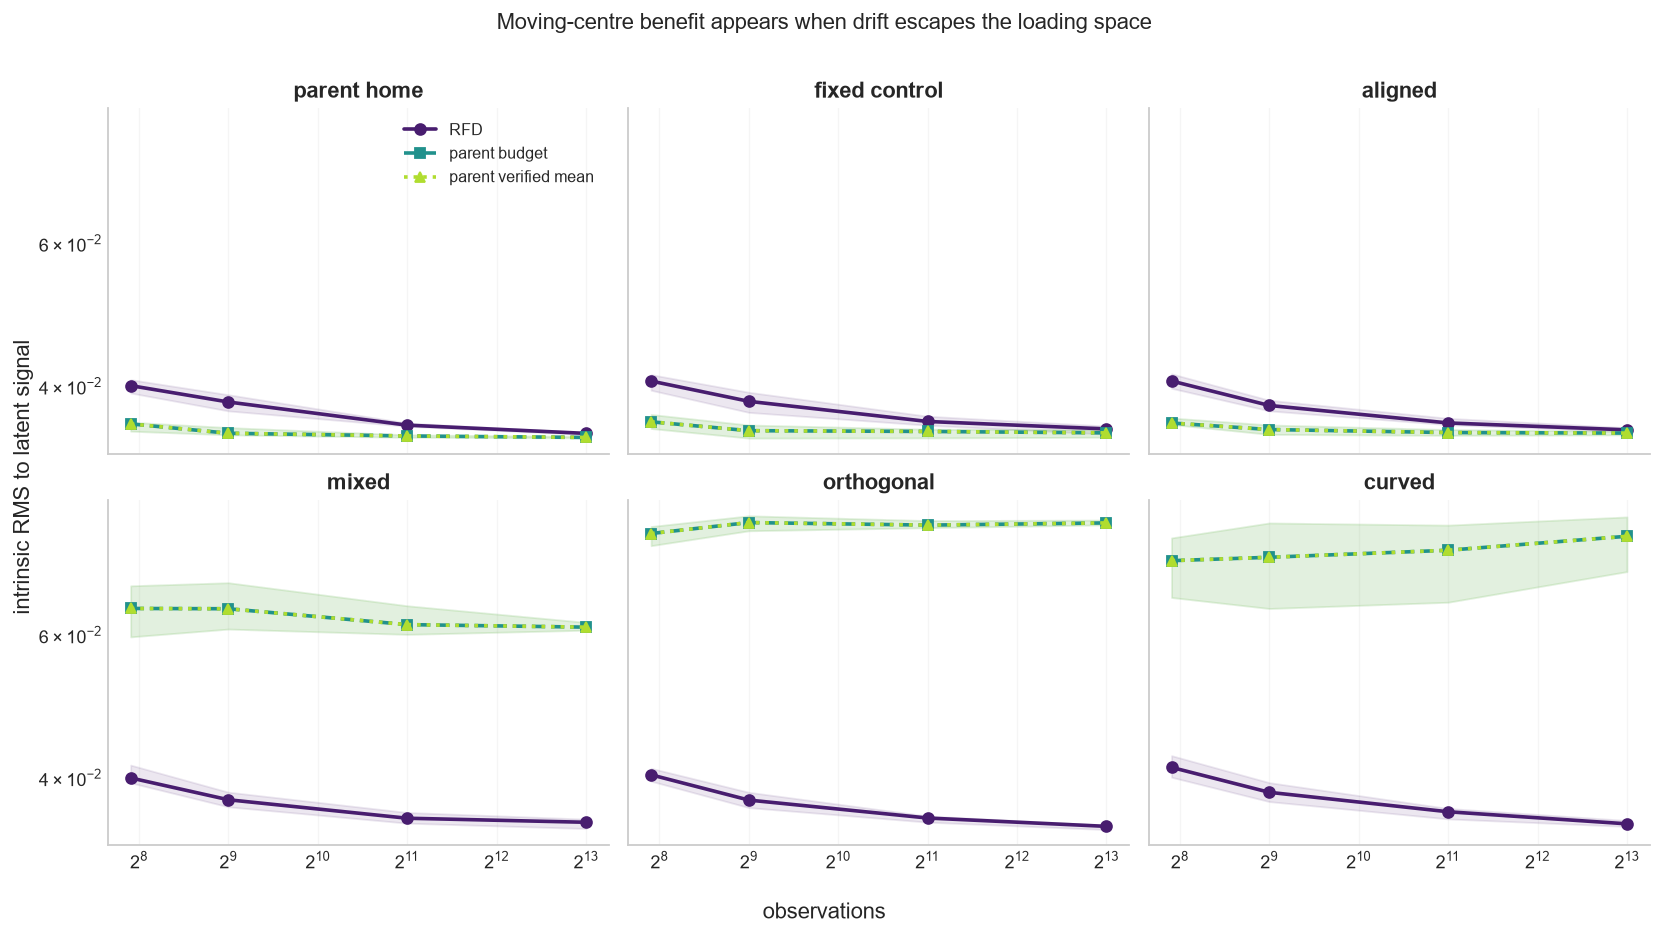

In [4]:
plot_signal_reconstruction(cells, EXPORT_DIR);

## Direct percentage-gain map

The annotations are deliberately ordinary percentages: positive favours RFD, negative favours the parent.

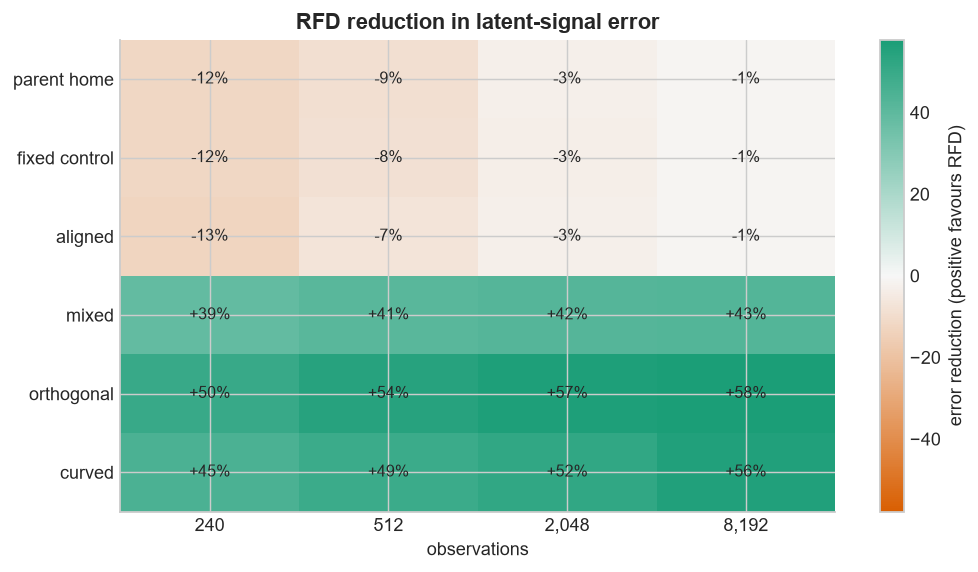

In [5]:
plot_signal_gain_heatmap(cells, EXPORT_DIR);

## Better centre versus better reconstruction

This is the identification figure. Better centre estimation need not improve reconstruction when drift lies inside the loading space.

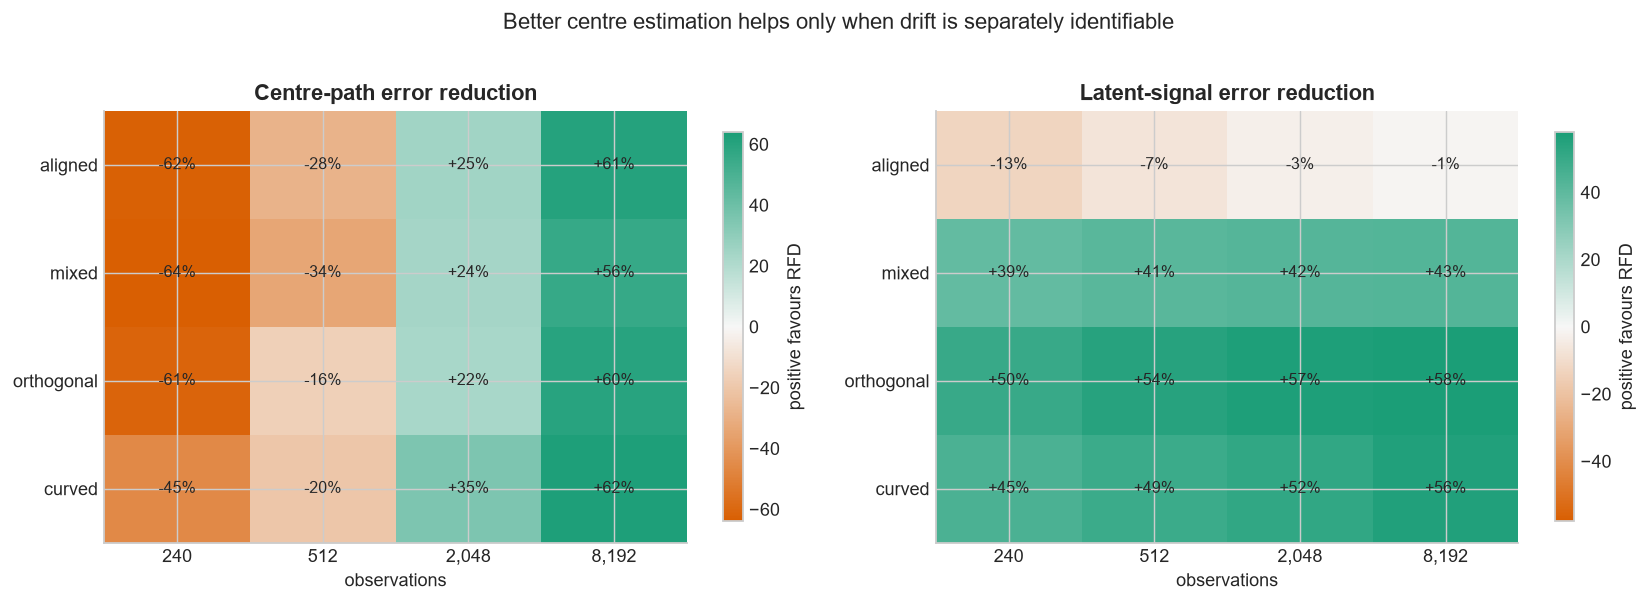

In [6]:
plot_centre_vs_signal(cells, EXPORT_DIR);

## Loading space and factor scores

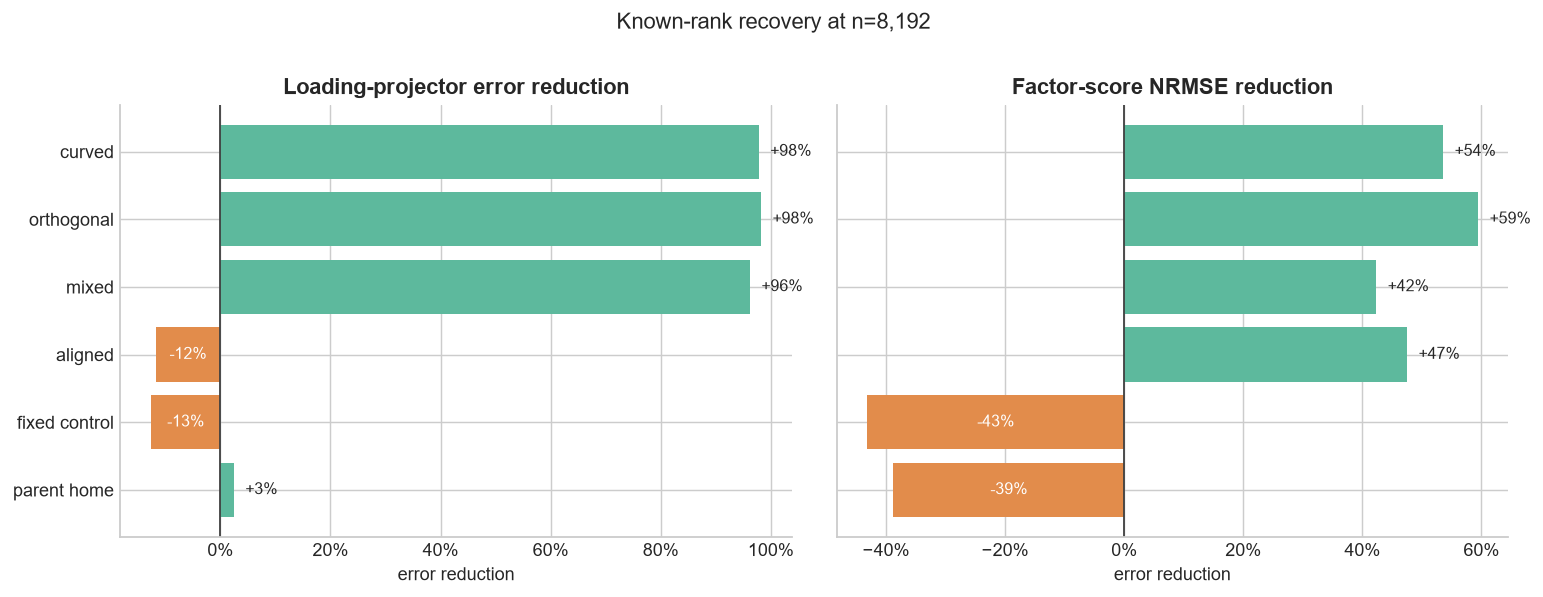

In [7]:
plot_loading_and_score_gain(cells, n=8192, export_dir=EXPORT_DIR);

## Paired-draw distributions

Every point is one paired draw. Zero means equal latent-signal error.

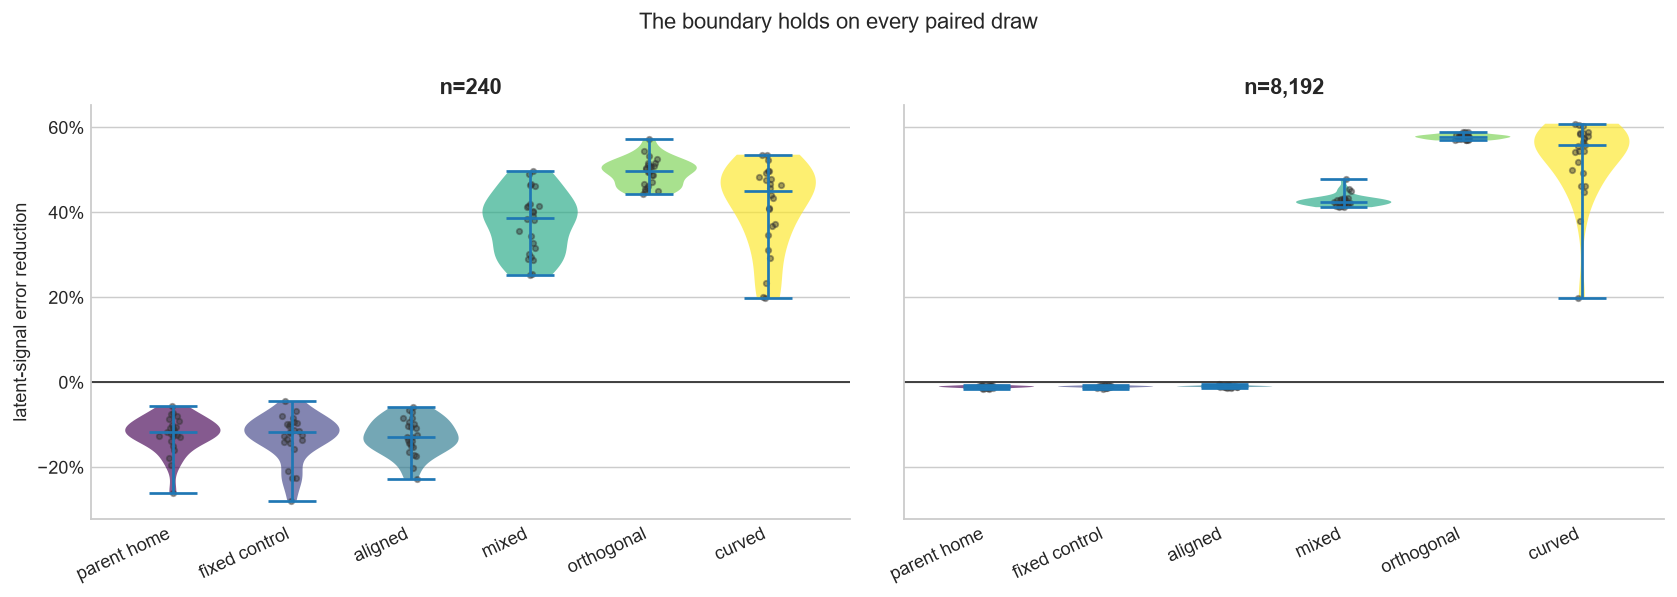

In [8]:
plot_paired_gain(raw, n_values=(240, 8192), export_dir=EXPORT_DIR);

## Fitting observations versus recovering the latent signal

Points above the diagonal gain more on the noiseless target than on the noisy observations.

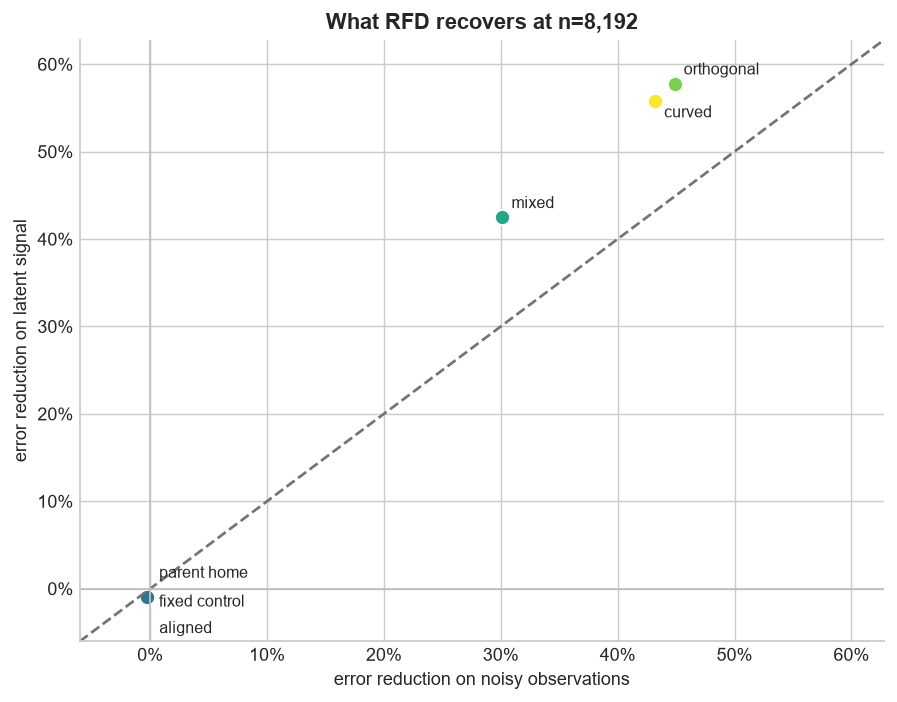

In [9]:
plot_observation_vs_signal(cells, n=8192, export_dir=EXPORT_DIR);

## Centre-rate diagnostic

The dotted reference is $n^{-3/7}$, anchored to the first median in each panel.

,scenario,observed exponent
0,parent home,0.374
1,fixed control,0.370
2,aligned,0.410
3,mixed,0.382
4,orthogonal,0.384
5,curved,0.401


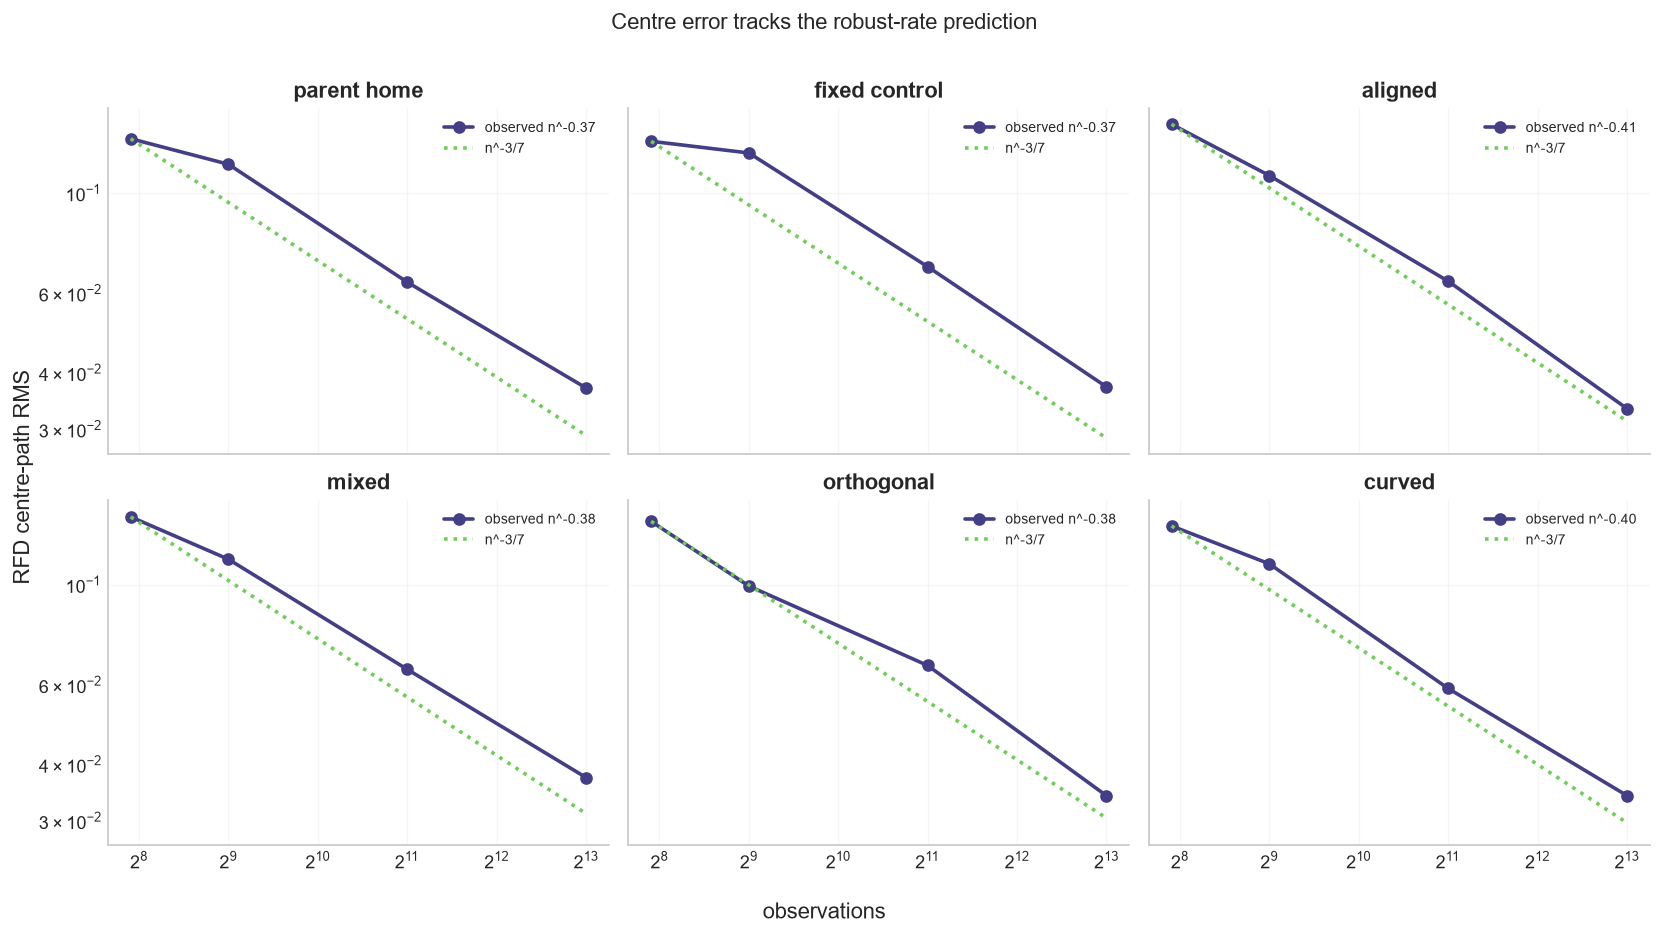

In [10]:
plot_centre_rate(cells, EXPORT_DIR);
display(centre_exponents(cells).round({"observed exponent": 3}))

## Parent global-mean sensitivity

This tests whether the verdict is merely caused by the parent's published stochastic mean budget.

,metric,median (%),p95 (%),maximum (%)
0,loading,0.0205,0.3119,2.6942
1,score,0.0012,0.0100,0.0866
2,observation,0.0008,0.0072,0.0700
3,latent signal,0.0007,0.0095,0.1015


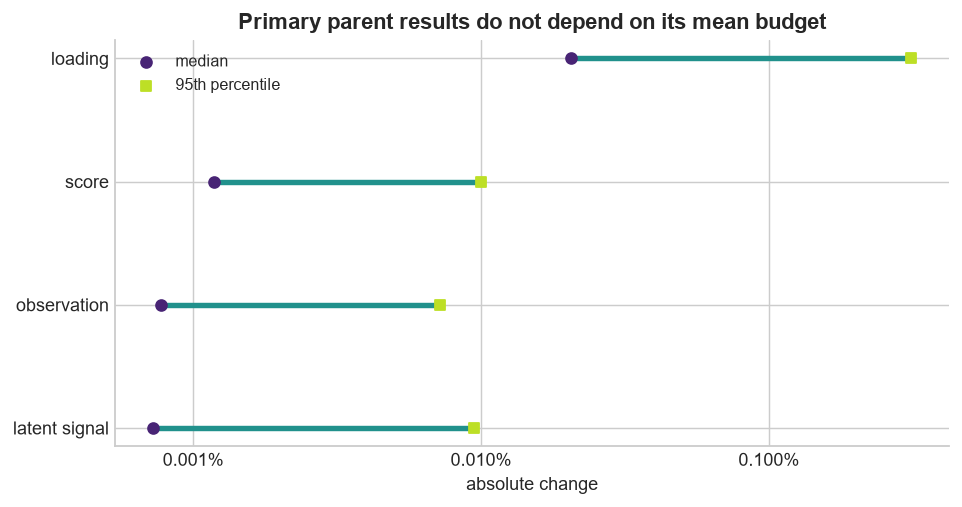

In [11]:
plot_parent_mean_sensitivity(raw, EXPORT_DIR);
display(parent_mean_sensitivity(raw).round(4))

## Runtime

,n,task_minutes,rfd_minutes,parent_minutes,generation_minutes
0,240,0.562,0.171,0.337,0.055
1,512,1.222,0.458,0.711,0.121
2,2048,5.394,2.395,2.535,0.466
3,8192,26.000,14.288,9.974,1.843


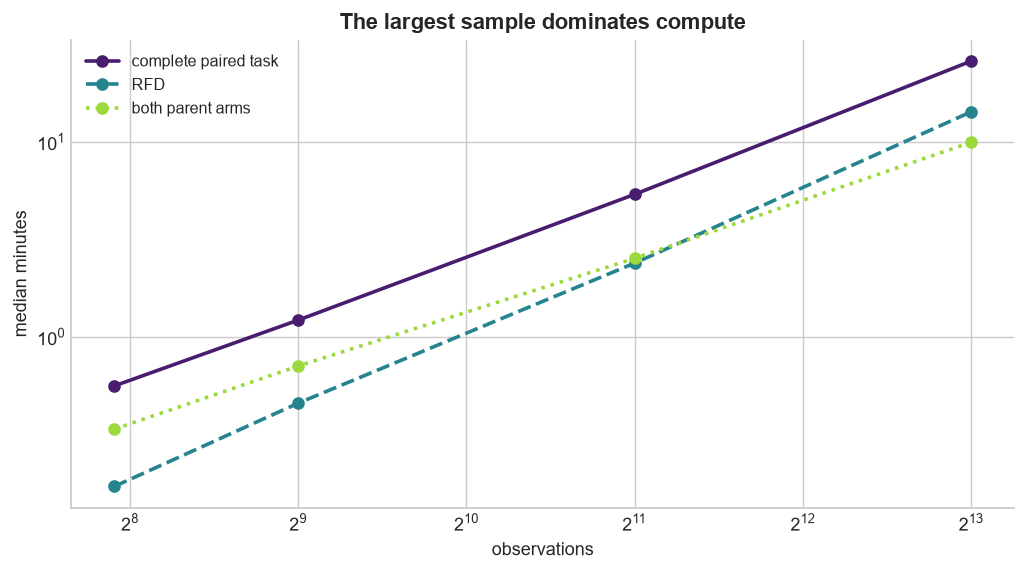

In [12]:
plot_runtime(raw, EXPORT_DIR);
display(runtime_table(raw).round(3))

## Reading boundary

- RFD pays a finite-sample price on fixed-centre and aligned-drift cells.
- It earns its complexity when centre drift has mixed, orthogonal, or curved components outside the loading space.
- The aligned cell shows why centre/factor identification is the scientific core: centre estimation improves without a reconstruction win.
- Score recovery remains a known-factor synthetic diagnostic, not a forecast.

Set `EXPORT = True` in the setup cell to save subsequently executed figures as PNG and SVG under `results/figures/parent_rfd_bw_parity/`.